In [1]:
import numpy as np
import matplotlib.pyplot as plt


## integrado en r con cortes en z

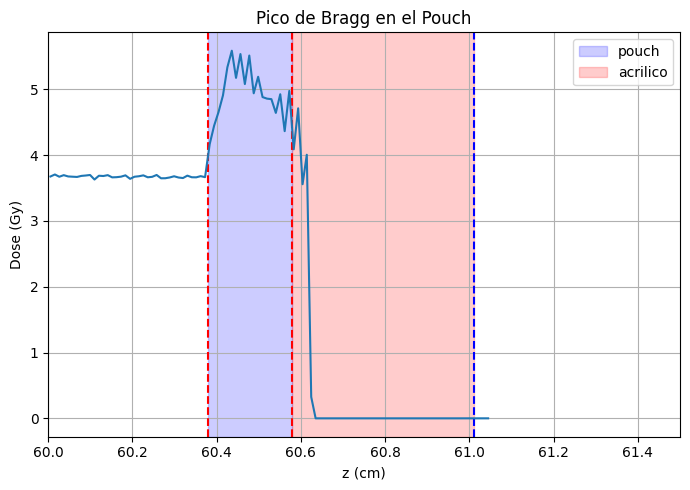

In [2]:
#DOSIS VS Z
archivo = "bragg_pouch_zcilindJesus_M0.out"

tiemporad = 300

z = []
dose = []


with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()


        if len(parts) != 4:
            continue


        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
            err = float(parts[3].replace("D", "E"))
        except:
            continue


        z.append((z1 + z2) / 2)
        dose.append(d)


plt.figure(figsize=(7,5))

plt.axvline(x=60.58,color='r', linestyle='--')
plt.axvline(x=60.38, color = 'r', linestyle='--')
plt.axvline(x=61.01, color = 'b', linestyle='--')
#plt.axvline(x = 60.23, color = 'g', linestyle='--'  )

plt.axvspan(60.38, 60.58, color='b', alpha=0.2, label='pouch')
plt.axvspan(60.58, 61.01, color='r', alpha=0.2, label='acrilico')
#plt.axvspan(60.23, 60.58, color='g', alpha=0.2, label='gel de ultrasonido')

plt.xlim(60,61.5)
plt.legend()
plt.plot(z, np.array(dose)*tiemporad)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy)") # gray por particula simulada (u)
plt.title("Pico de Bragg en el Pouch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# quiero calcular las 2 posiciones en z que le corresponde a Dose = 0.122 Gy
z = np.array(z)
dose = np.array(dose)

dose_corte = 3.9/tiemporad

zcortes = []

for i in range(len(z)-1):
    if (dose[i] - dose_corte) * (dose[i+1] - dose_corte) <= 0:
        zc = z[i] + (dose_corte - dose[i]) * (z[i+1] - z[i]) / (dose[i+1] - dose[i])
        zcortes.append(zc)

print(f"Para Dose = {dose_corte} Gy, los valores de z son:")

for zc in zcortes:
    print(f"{zc:.4f} cm")

Para Dose = 0.013 Gy, los valores de z son:
60.3777 cm
60.6009 cm
60.6117 cm
60.6143 cm


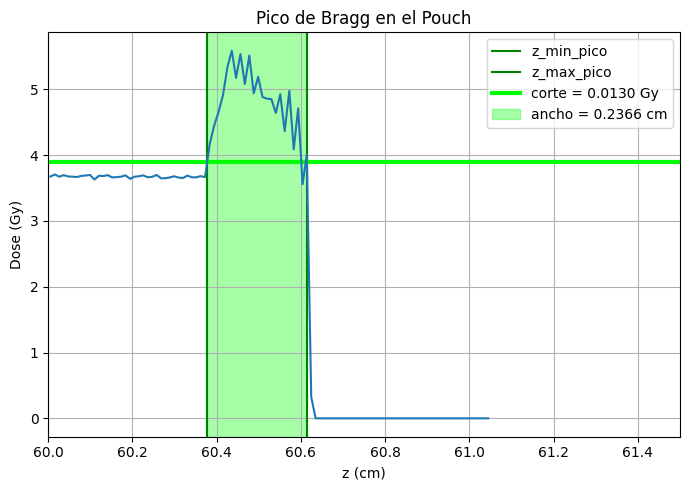

z_min = 60.3777 cm
z_max = 60.6143 cm
ancho = 0.2366 cm
ancho = 2.37 mm


In [19]:
z_pouch_min = min(zcortes)
z_pouch_max = max(zcortes)

z_pico_min = zcortes[0]
z_pico_max = zcortes[-1]

ancho_pico = z_pico_max - z_pico_min

plt.figure(figsize=(7,5))

plt.axvline(x=z_pico_min, color='green', label='z_min_pico')
plt.axvline(x=z_pico_max, color='green',  label='z_max_pico')


plt.axhline(dose_corte*tiemporad, color='lime', linewidth=3, label=f'corte = {dose_corte:.4f} Gy')
plt.axvspan(z_pico_min, z_pico_max, color='lime', alpha=0.35, label=f'ancho = {ancho_pico:.4f} cm')

plt.plot(z, dose*tiemporad)

plt.xlim(60., 61.5)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy)")
plt.title("Pico de Bragg en el Pouch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"z_min = {z_pico_min:.4f} cm")
print(f"z_max = {z_pico_max:.4f} cm")
print(f"ancho = {ancho_pico:.4f} cm")
print(f"ancho = {ancho_pico*10:.2f} mm")

## integrado en z con cortes en r

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import re

Cantidad de bins radiales leídos: 100
Dosis mínima: 0.0073982
Dosis máxima: 0.015071
Dosis media: 0.010408475000000002
Error relativo medio: 0.007112


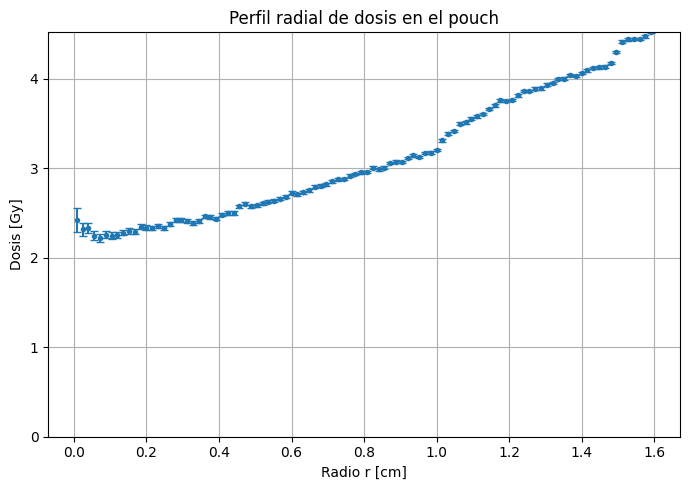

In [33]:
archivo = "bragg_pouch_rcilindJesus.out"

rmin = []
rmax = []
dosis = []
err_rel = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

i = 0
while i < len(lineas):
    linea = lineas[i]

    match = re.search(r"r = \(\s*([+-]?\d+\.\d+E[+-]\d+)\s*-\s*([+-]?\d+\.\d+E[+-]\d+)\s*\)", linea)

    if match:
        r1 = float(match.group(1))
        r2 = float(match.group(2))

        for j in range(i, min(i + 30, len(lineas))):
            partes = lineas[j].split()

            if len(partes) == 4:
                try:
                    z_lower = float(partes[0])
                    z_upper = float(partes[1])
                    d = float(partes[2])
                    e = float(partes[3])

                    if 50 < z_lower < 70 and 50 < z_upper < 70:
                        rmin.append(r1)
                        rmax.append(r2)
                        dosis.append(d)
                        err_rel.append(e)
                        break

                except ValueError:
                    pass

    i += 1

rmin = np.array(rmin)
rmax = np.array(rmax)
dosis = np.array(dosis)
err_rel = np.array(err_rel)

r_centro = 0.5 * (rmin + rmax)
err_abs = dosis * err_rel

print("Cantidad de bins radiales leídos:", len(dosis))
print("Dosis mínima:", np.min(dosis))
print("Dosis máxima:", np.max(dosis))
print("Dosis media:", np.mean(dosis))
print("Error relativo medio:", np.mean(err_rel))


plt.figure(figsize=(7, 5))
plt.errorbar(
    r_centro,
    dosis * 300,
    yerr = err_abs * 300,
    fmt=".",
    capsize=3
)

plt.xlabel("Radio r [cm]")
plt.ylabel("Dosis [Gy]")
plt.ylim(0, np.max(dosis * 300))
plt.title("Perfil radial de dosis en el pouch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
factor = 300
dosis_graf = dosis * factor

media = np.mean(dosis_graf)
desvio = np.std(dosis_graf)
cv = 100 * desvio / media

d_min = np.min(dosis_graf)
d_max = np.max(dosis_graf)

homogeneidad_min_max = 100 * (1 - (d_max - d_min) / media)

print("===== HOMOGENEIDAD RADIAL =====")
print(f"Dosis media: {media:.4f} Gy")
print(f"Desviación estándar: {desvio:.4f} Gy")
print(f"Coeficiente de variación: {cv:.2f} %")
print(f"Dosis mínima: {d_min:.4f} Gy")
print(f"Dosis máxima: {d_max:.4f} Gy")
print(f"Rango relativo respecto a la media: {100*(d_max-d_min)/media:.2f} %")

===== HOMOGENEIDAD RADIAL =====
Dosis media: 3.1225 Gy
Desviación estándar: 0.6953 Gy
Coeficiente de variación: 22.27 %
Dosis mínima: 2.2195 Gy
Dosis máxima: 4.5213 Gy
Rango relativo respecto a la media: 73.72 %
